In [1]:
import torch
import torch.nn as nn
import os
import numpy as np
from torchvision import models, transforms
from PIL import Image
from AdamLipPOT.LipPOT import LipPOT 

# --- IMPORT YOUR SAMPLER ---
# Assumes the previous code is saved as adam_sobol_sampler.py
from AdamSobolSamplingImagenet2 import AdamSobolSampler
from lipMIP.hyperbox import Hyperbox

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

Running on device: cuda


In [ ]:
# --- CONFIGURATION ---
FOLDER_NAME = "ImageNet"
WEIGHTS_FILENAME = "resnet50_weights.pth"
IMAGE_FILENAME = "tench.JPEG" 
EPSILON = 3/255  # The size of the attack box
# EPSILON = 0.05  # The size of the attack box
STEPS = 400     # Steps for Adam
WALKERS = 64    # Number of parallel restart points (Lower this if you get OOM)


# --- STEP 1: SETUP PATHS & WEIGHTS ---
current_dir = os.getcwd()
save_dir = os.path.join(current_dir, FOLDER_NAME)
weights_path = os.path.join(save_dir, WEIGHTS_FILENAME)
image_path = os.path.join(save_dir, IMAGE_FILENAME)
os.makedirs(save_dir, exist_ok=True)

weights_enum = models.ResNet50_Weights.DEFAULT
url = weights_enum.url

if not os.path.exists(weights_path):
    print(f"Downloading weights to {weights_path}...")
    torch.hub.download_url_to_file(url, weights_path)
else:
    print(f"Found local weights at {weights_path}")

# --- STEP 2: MODEL WRAPPER (CRITICAL) ---
# We define a wrapper that handles normalization.
# This allows the attacker to optimize in [0, 1] space, 
# while the ResNet receives the expected normalized values.

class NormalizedResNet(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        # Standard ImageNet normalization
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def forward(self, x):
        # x is expected to be [Batch, 3, 224, 224] in range [0, 1]
        x_norm = self.normalize(x)
        return self.base_model(x_norm)

# Load raw model
base_model = models.resnet50(weights=None)
state_dict = torch.load(weights_path, map_location=device)
base_model.load_state_dict(state_dict)

# Wrap it and move to device
model = NormalizedResNet(base_model).to(device)
model.eval()

# --- STEP 3: LOAD AND PREPROCESS IMAGE (0-1 Range) ---
# We manually define transforms to get the image into [0, 1] tensor
# but WITHOUT the normalization step (since the model wrapper does that).

preprocess_0_1 = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor() # Converts to [0, 1]
])

try:
    img_pil = Image.open(image_path).convert('RGB')
    x0 = preprocess_0_1(img_pil).unsqueeze(0).to(device) # Shape: (1, 3, 224, 224)
except FileNotFoundError:
    print(f"ERROR: Image not found at {image_path}")
    print("Please provide a valid image file.")
    exit()

# --- STEP 4: DETERMINE TARGET VECTOR (c_vector) ---
# Run inference to find the predicted class
with torch.no_grad():
    logits = model(x0)
    probs = logits.softmax(dim=1)
    pred_id = probs.argmax().item()
    pred_name = weights_enum.meta["categories"][pred_id]
    confidence = probs[0, pred_id].item()

print(f"\nTarget Image: {IMAGE_FILENAME}")
print(f"Prediction: {pred_name} (ID: {pred_id})")
print(f"Confidence: {confidence*100:.2f}%")

# Define c_vector. 
# If we want to measure the gradient norm of the predicted class score:
c_vector = torch.zeros((1, 1000), device=device)
c_vector[0, pred_id] = 1.0

# --- STEP 5: CONFIGURE DOMAIN ---
print("\n--- CONFIGURING ATTACK ---")
print(f"Epsilon: {EPSILON}")

# Define the Hyperbox around x0
# The sampler clamps to [0,1], but we also need the box bounds to be in [0,1]
box_low = torch.clamp(x0 - EPSILON, 0.0, 1.0)
box_hi = torch.clamp(x0 + EPSILON, 0.0, 1.0)

# Create Hyperbox instance
# Note: We pass the full number of parameters (3*224*224) as the dimension
flat_dim = x0.numel() 
domain = Hyperbox.build_unit_hypercube(flat_dim)
domain.box_low = box_low
domain.box_hi = box_hi


Found local weights at /home/milan/LBDN/ImageNet/resnet50_weights.pth

Target Image: tench.JPEG
Prediction: tench (ID: 0)
Confidence: 43.97%

--- CONFIGURING ATTACK ---
Epsilon: 0.03137254901960784


Starting sampler...

--- STAGE 1: Running 'adam_topm' attack ---
Starting Adam 'tanh' attack (ImgNet) with 64 restarts...


Adam (tanh) Attack: 100%|██████████| 400/400 [01:15<00:00,  5.30it/s]



--- STAGE 2: Spatial Decorrelation ---
Post-NMS samples: 314

--- STAGE 3: Selecting Top 20 diverse peaks ---

--- STAGE 4: Generating Sobol samples in 20 sub-regions ---

--- STAGE 5: Second refinement, picking top 20 and regenerating sobol samples
Applying Jitter (+/- 0.5)...

--- SAMPLING COMPLETE ---
Found 8000 samples.
Max Gradient Norm Found: 15578.0168
Avg Gradient Norm Found: 12338.5797
Saved image with highest gradient to high_grad_tench.png
[ThresholdAnalyzer] PyTorch is available. Using device: cuda

[PyTorch Backend] Starting computation from the 80th percentile of peaks.
Computing MRL statistics for up to 1600 candidate thresholds...
Computation complete. Found 1590 valid candidate thresholds.
Starting binary search on 1590 computed thresholds...

[PyTorch Backend] Found optimal threshold: 13243.95.

--- Results ---
Execution time: 0.2336 seconds
The algorithm identified an optimal threshold of: 13243.95
This corresponds to the 83.08% quantile of the original data.

Gener

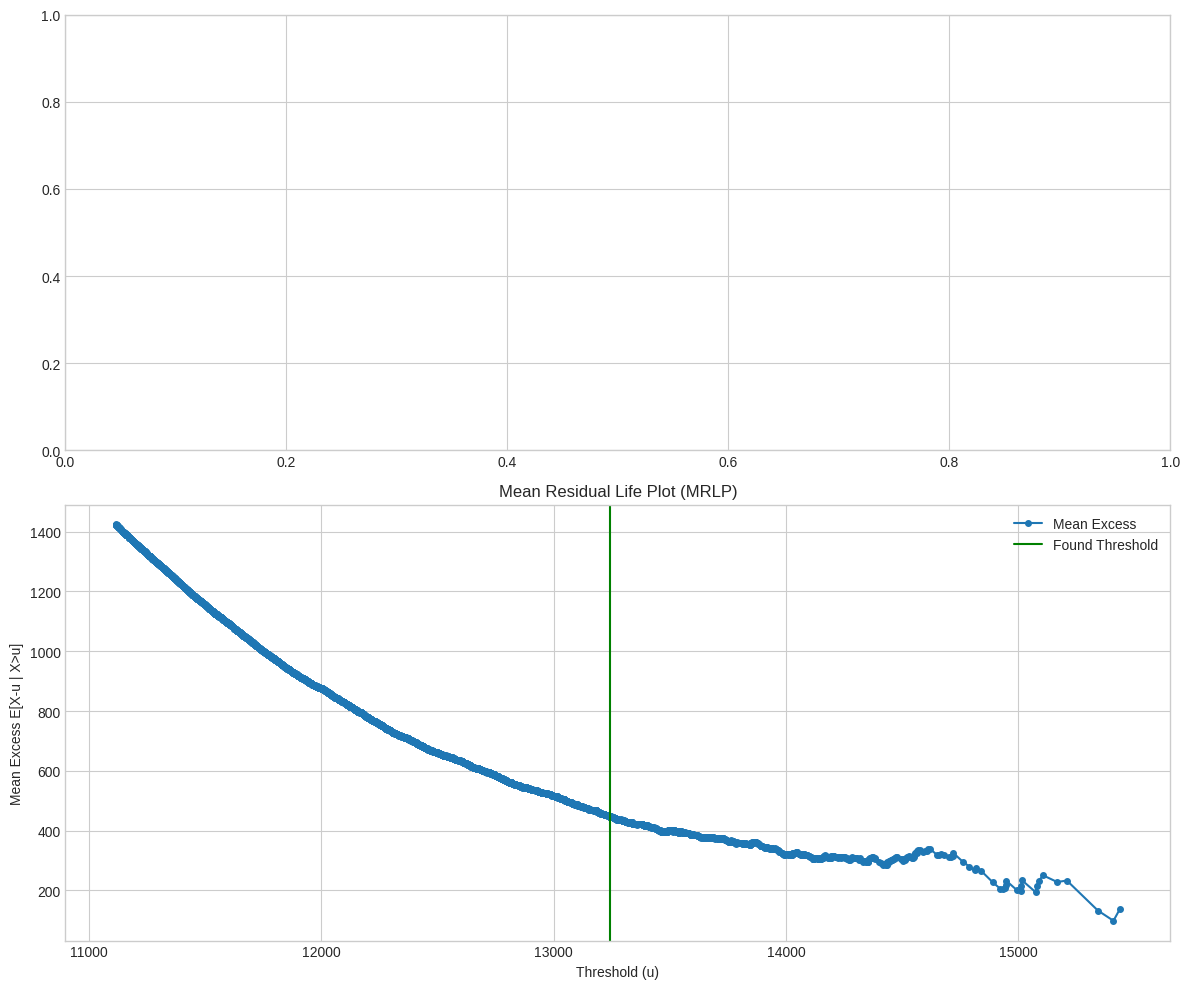


INITIAL POT ANALYSIS (ENDPOINT)
Total Samples (N_total): 8000
Threshold (u): 13243.9473
Number of Excesses (N_u): 1354
Confidence (1-gamma): 0.95
DKW Epsilon (for excesses): 0.036908
Kolmogorov-Smirnov D_NS (GPD fit): 0.025929
Central GPD Fit: Shape=-0.1646, Scale=518.7616
--> Initial Endpoint Estimate: 16395.6859


--- Starting Constrained Optimization for Max Endpoint ---
Step 1: Checking if Infinite Endpoint is feasible...
Step 2: Infinite endpoint not feasible. Maximizing finite endpoint...
Singular matrix E in LSQ subproblem    (Exit mode 5)
            Current function value: -7.105427357601028e+30
            Iterations: 46
            Function evaluations: 138
            Gradient evaluations: 46
Optimizer finished with message: Singular matrix E in LSQ subproblem
Result Endpoint: 7.11e+30 (Hit Cap: False)
Constraint Validity: False
Starting initial search for acceptable parameter space (10,000 samples)...
Found 697 valid parameter sets in initial search.

Starting fine-graini

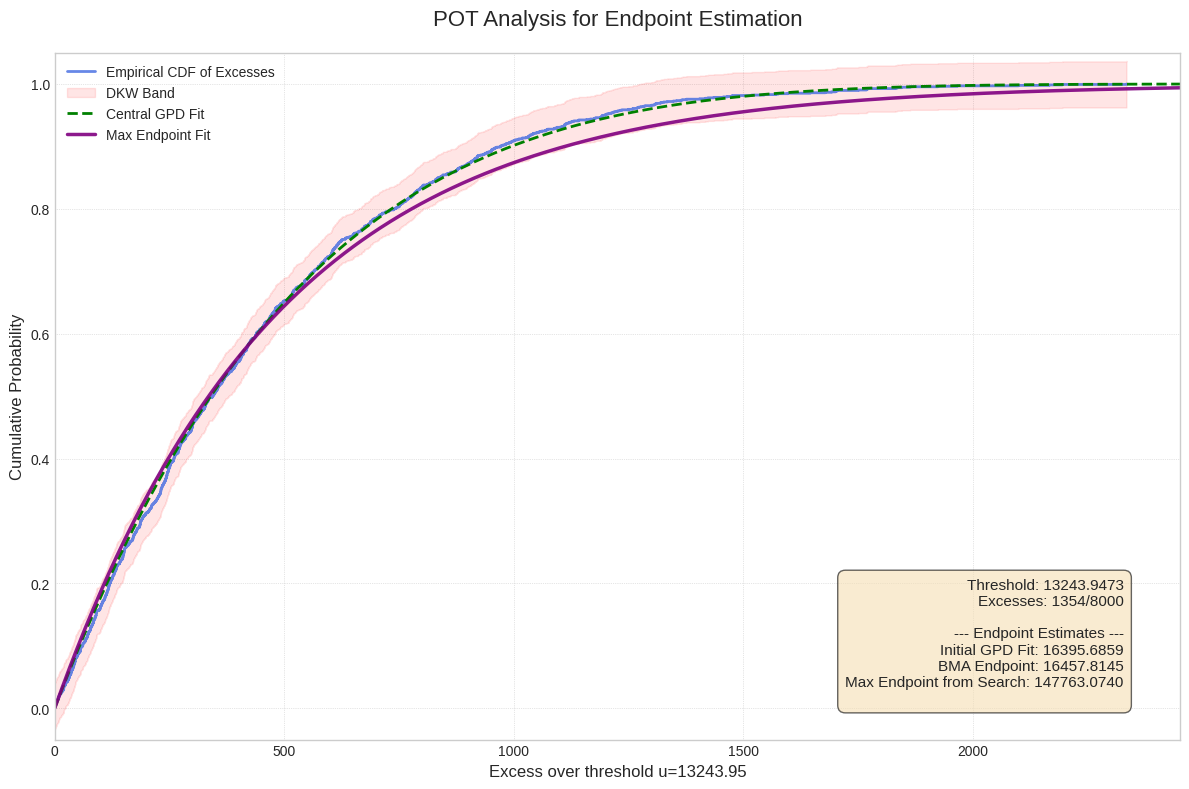

: 

In [ ]:
# --- STEP 6: RUN SAMPLER ---
sampler = AdamSobolSampler(
    model=model,
    c_vector=c_vector,
    domain=domain,
    device=device,
    attack_type='adam_topm', # Use the top-m strategy
    norm_type='linf',        # L-infinity norm
    steps=STEPS,
    walkers=WALKERS,         # Parallel restarts
    step_size=0.005,         # Learning rate
    top_m=5,                 # Keep top 5 peaks per restart
    nms_radius=0.5*EPSILON,          # Decorrelation radius
    top_k_refine=20,         # Refine the top 10 best regions found
    batch_size=16            # Batch size for Sobol evaluation
)

print("Starting sampler...")
final_inputs, final_grad_norms = sampler.run()

# --- STEP 7: RESULTS ---
print("\n--- SAMPLING COMPLETE ---")
print(f"Found {len(final_grad_norms)} samples.")
if len(final_grad_norms) > 0:
    max_grad = np.max(final_grad_norms)
    avg_grad = np.mean(final_grad_norms)
    print(f"Max Gradient Norm Found: {max_grad:.4f}")
    print(f"Avg Gradient Norm Found: {avg_grad:.4f}")
    
    # Optional: Save the input with the highest gradient
    best_idx = np.argmax(final_grad_norms)
    best_input = final_inputs[best_idx] # (3, 224, 224)
    
    # Convert back to PIL to save
    best_img_tensor = torch.from_numpy(best_input)
    to_pil = transforms.ToPILImage()
    best_img_pil = to_pil(best_img_tensor)
    best_img_pil.save(os.path.join(save_dir, f"high_grad_{pred_name}.png"))
    print(f"Saved image with highest gradient to high_grad_{pred_name}.png")


    lippot_results = LipPOT.run_full_analysis(
        data = final_grad_norms,
        coords = final_inputs, 
        gamma = 0.05, 
        n_search_samples=10000,
        show_plot=True,
        use_fine_graining=True,
        verbose=True
    )



else:
    print("No samples found.")